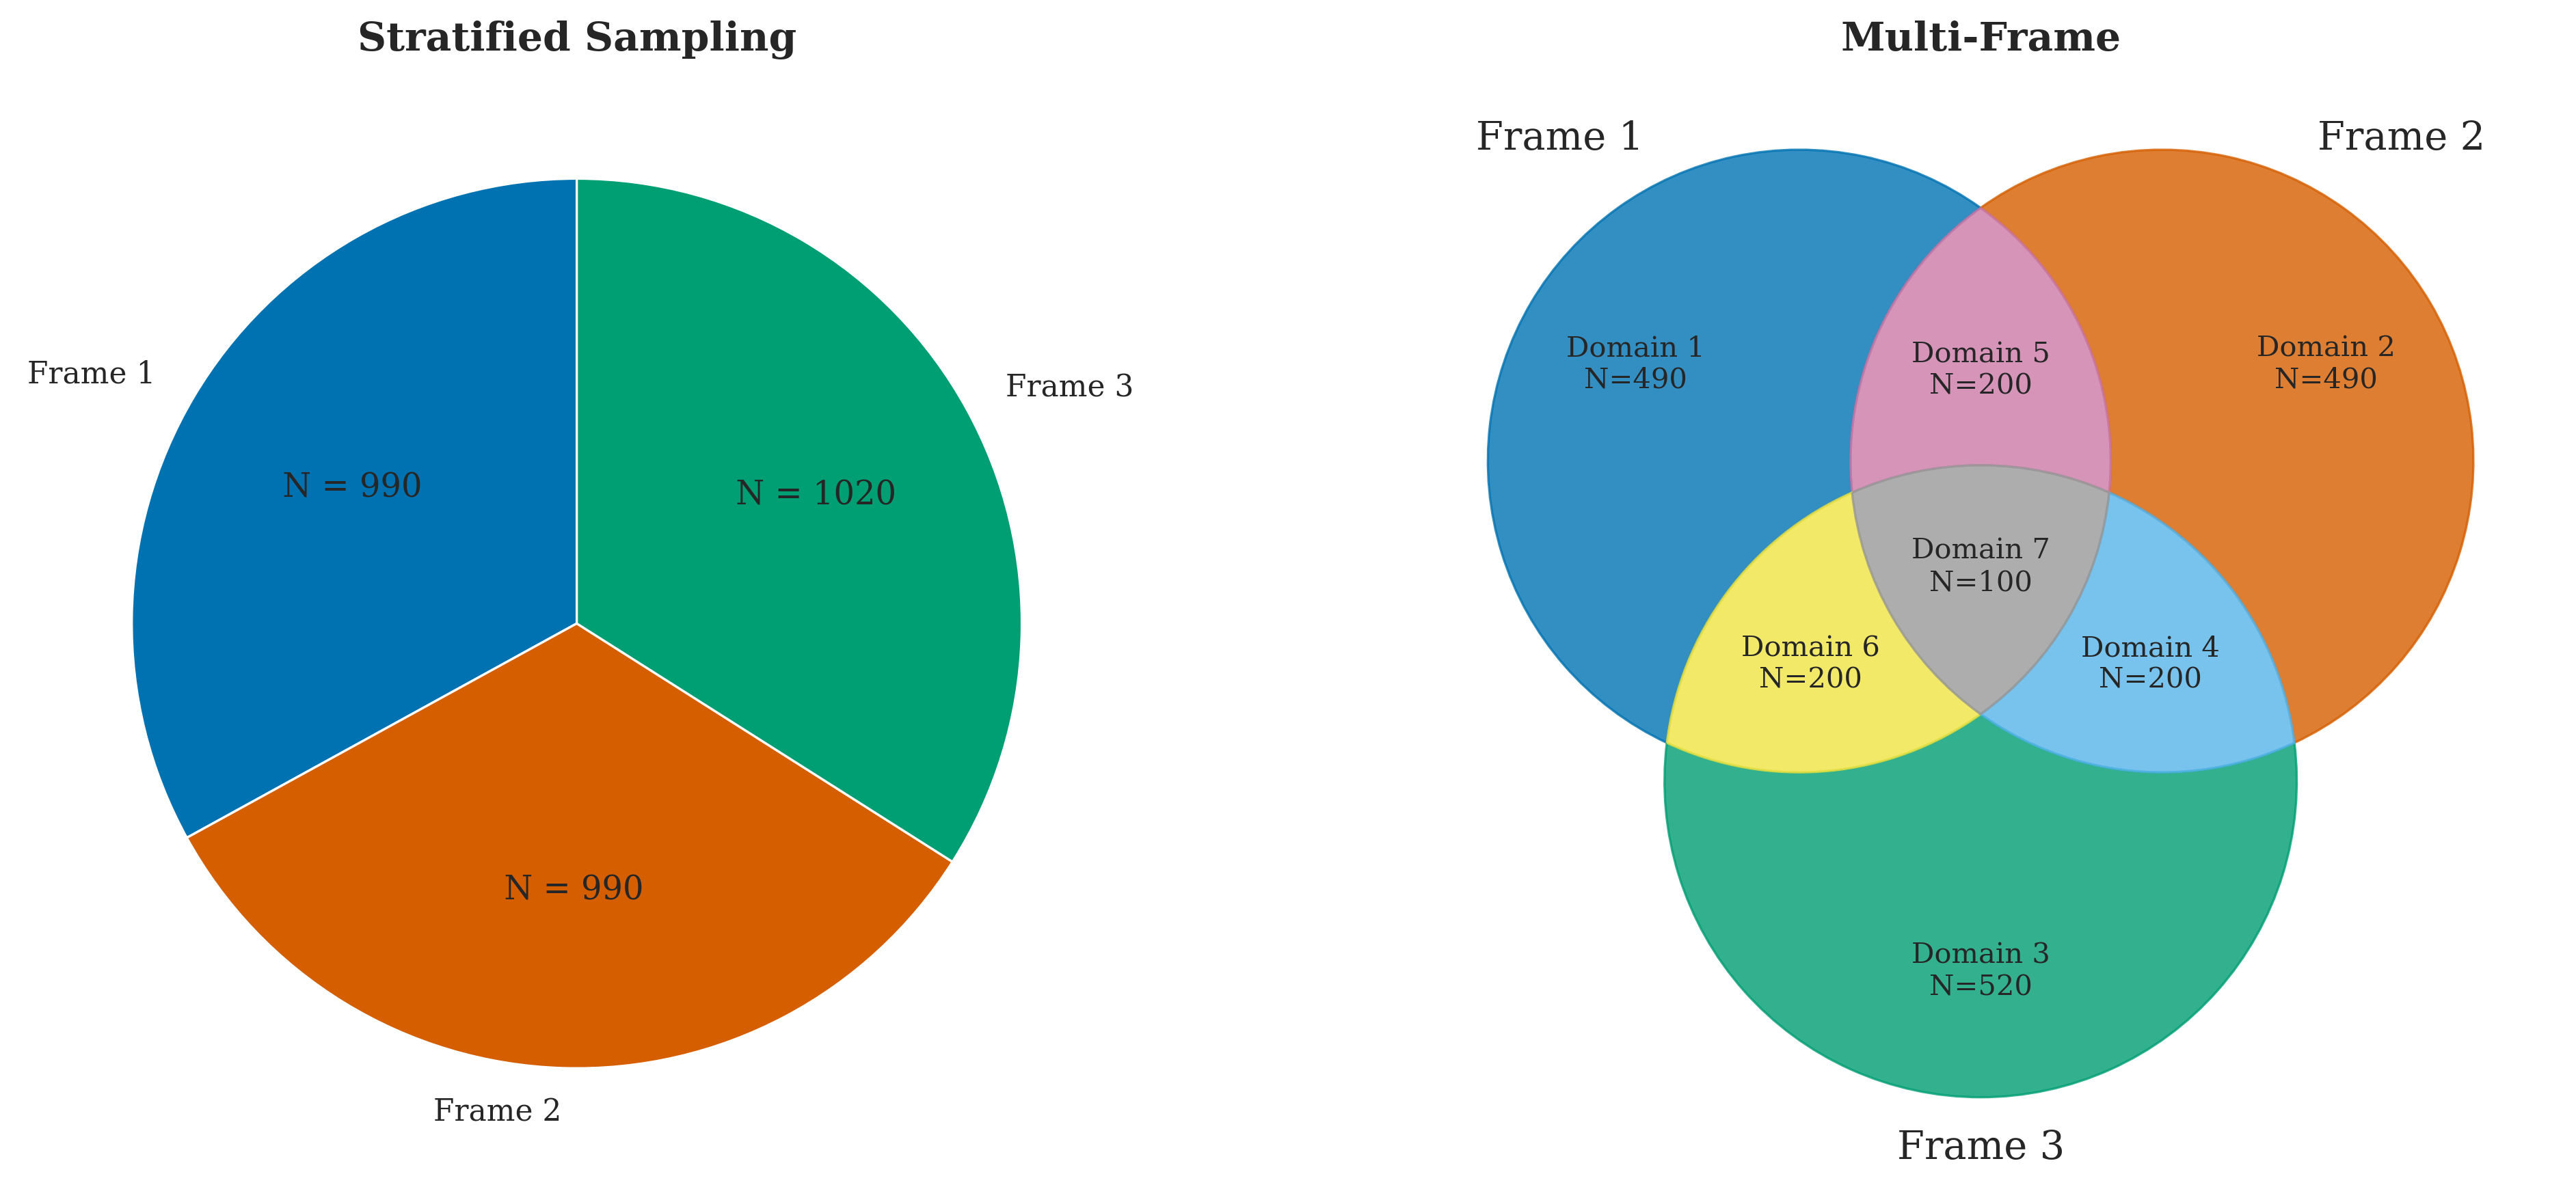

In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import seaborn as sns
import pandas as pd

sns.set_theme(context="paper",
              style="white",
              font="serif",
              font_scale=1.2,
              rc={"figure.dpi": 300})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


##########################################################################################
### MULTIFRAME VENN DIAGRAM WITH 7 DOMAINS
##########################################################################################


# -----------------------------
# Domain populations (edit if needed)
# -----------------------------
domains = {
    "D1": 490,   # A only
    "D2": 490,   # B only
    "D3": 520,   # C only
    "D4": 200,   # B ∩ C only
    "D5": 200,   # A ∩ B only
    "D6": 200,   # A ∩ C only
    "D7": 100    # A ∩ B ∩ C
}

# Order for venn3 subsets:
# (A, B, A∩B, C, A∩C, B∩C, A∩B∩C)
subsets = (
    domains["D1"],  # A only
    domains["D2"],  # B only
    domains["D5"],  # A ∩ B
    domains["D3"],  # C only
    domains["D6"],  # A ∩ C
    domains["D4"],  # B ∩ C
    domains["D7"]   # A ∩ B ∩ C
)

# -----------------------------
# Create the figure
# -----------------------------
v = venn3(
    subsets=subsets,
    set_labels=("Frame 1", "Frame 2", "Frame 3"),
    ax=axes[1]
)


# -----------------------------
# Give each domain (region) a different color
# Region IDs:
# '100' A only, '010' B only, '110' A∩B,
# '001' C only, '101' A∩C, '011' B∩C, '111' A∩B∩C
# -----------------------------
region_colors = {
    '100': "#0072B2",  # Domain 1
    '010': "#D55E00",  # Domain 2
    '001': "#009E73",  # Domain 3
    '110': "#CC79A7",  # Domain 5
    '101': "#F0E442",  # Domain 6
    '011': "#56B4E9",  # Domain 4
    '111': "#999999"   # Domain 7
}

for rid, color in region_colors.items():
    patch = v.get_patch_by_id(rid)
    if patch is not None:
        patch.set_color(color)
        patch.set_alpha(0.8)

# -----------------------------
# Label regions with domain IDs (and optionally N)
# -----------------------------
region_labels = {
    '100': f"Domain 1\nN={domains['D1']}",
    '010': f"Domain 2\nN={domains['D2']}",
    '001': f"Domain 3\nN={domains['D3']}",
    '110': f"Domain 5\nN={domains['D5']}",
    '101': f"Domain 6\nN={domains['D6']}",
    '011': f"Domain 4\nN={domains['D4']}",
    '111': f"Domain 7\nN={domains['D7']}",
}

for rid, text in region_labels.items():
    label = v.get_label_by_id(rid)
    if label is not None:
        label.set_text(text)
        label.set_fontsize(10, )

# -----------------------------
# Final styling
# -----------------------------
axes[1].set_title("Multi-Frame", fontsize=14, fontweight="bold")


################################
#### STS PIE CHART
################################

# STS strata
axes[0].set_title("Stratified Sampling", fontsize=14, fontweight="bold")
sts = pd.Series([990, 990, 1020], index=["Frame 1", "Frame 2", "Frame 3"])

# --- Domain colors for consistency with MFS ---
domain_colors = {
    "Domain 1": "#0072B2",  # example: blue
    "Domain 2": "#D55E00",  # example: vermillion
    "Domain 3": "#009E73",  # example: bluish-green
}

# Apply domain 1–3 colors to STS strata
sts_colors = [
    domain_colors["Domain 1"],
    domain_colors["Domain 2"],
    domain_colors["Domain 3"]
]

# --- Custom autopct to show integer values ---
def autopct_int(values):
    def inner_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f" N = {val}"
    return inner_autopct

# --- Pie chart 1: STS ---
axes[0].pie(
    sts,
    labels=sts.index,
    autopct=autopct_int(sts),
    startangle=90,
    colors=sts_colors
)


plt.tight_layout()
plt.show()
